## MSM.jl and Dynare.jl: estimating a DSGE model

This notebook repeats the estimation of [`../RBC.ipynb`](../RBC.ipynb) on a single fake dataset, but the model is written, solved and simulated with [Dynare.jl](https://github.com/DynareJulia/Dynare.jl) instead of [MacroModelling.jl](https://github.com/thorek1/MacroModelling.jl). 

The steps are the same as in `RBC.ipynb`:
1. take a model with known ("true") parameters;
2. solve it, simulate time series and save them to disk: this is our (fake) "empirical data";
3. estimate the parameters by the method of simulated moments, from the fake data only;
4. check that the true parameters are recovered.

The two notebooks use the same model, calibration, moments, seeds and settings, so they should give the same fake data and the same estimates: this is checked below. An optional section at the end estimates the model again with the method of moments of Dynare for Octave, as an independent check. 

**What Dynare.jl offers (version 0.10.4).** Dynare.jl is the Julia version of [Dynare](https://www.dynare.org). It solves models at first order only (`stoch_simul(order = 1)`). Unless I am mistaken, I do not believe that Dynare.jl currently offers method of moments estimation (unlike Dynare v4.7+ for MATLAB, with `method_of_moments`).

**Environment.** This notebook has its own environment (`notebooks/models/dynare/Project.toml`), separate from the one of `RBC.ipynb`: Dynare.jl requires older versions of some packages (CSV 0.10, Optim 1), and its documentation recommends installing it in a fresh environment. Install it once with `julia --project=notebooks/models/dynare -e 'using Pkg; Pkg.instantiate()'`. The notebook uses functions of Dynare.jl that are internal (see below), so `Project.toml` pins Dynare.jl to version 0.10.4.

### Settings

In [1]:
T = 200                    # length of the fake data (quarters)
simulationRatio = 10       # the simulated sample has simulationRatio*T periods
burnIn = 200               # periods dropped at the start of each simulation
nbSimulationsSigma0 = 500  # simulated datasets used for the model-based Sigma0

addWorkers = true
maxNumberWorkers = 10      # number of workers used when minimizing

10

In [2]:
using Distributed

if addWorkers == true && nworkers() < maxNumberWorkers
    # the workers use the environment of this notebook
    addprocs(maxNumberWorkers - (nprocs() - 1), exeflags = "--project=$(Base.active_project())")
end
println("Number of workers = $(nworkers())")

Number of workers = 10


In [3]:
using Plots
using CSV
using DataFrames
using Distributions: Normal
# Dynare.jl is imported, not loaded with `using`: every call below is written Dynare.function_name
@everywhere import Dynare
@everywhere using MSM
@everywhere using Optim
@everywhere using OrderedCollections
@everywhere using Random
@everywhere using LinearAlgebra
@everywhere using Logging
@everywhere using Statistics: mean, std, median, cov, quantile

# Hide the messages of level Info: MSM.jl logs one for each failed evaluation of the model
# (e.g. when the local optimizer tries parameter values for which the model has no stable solution)
@everywhere disable_logging(Logging.Info)

### The model

The model is the real business cycle model of `RBC.ipynb`, with consumption $c$, capital $k$, output $y$ and technology $z$:

$$\frac{1}{c_t} = \beta \, E_t \left[ \frac{1}{c_{t+1}} \left( \alpha e^{z_{t+1}} k_t^{\alpha - 1} + 1 - \delta \right) \right]$$
$$c_t + k_t = (1 - \delta) k_{t-1} + y_t$$
$$y_t = e^{z_t} k_{t-1}^{\alpha}$$
$$z_t = \rho z_{t-1} + \sigma_z \epsilon_t$$

The calibration is quarterly: $\beta = 0.99$, $\delta = 0.025$, $\alpha = 0.33$, $\rho = 0.9$ and $\sigma_z = 0.7\%$. We estimate $(\alpha, \rho, \log(\sigma_z))$, with $\sigma_z$ in percent, and hold $\beta$ and $\delta$ fixed at their true values (see `RBC.ipynb` for why we estimate the logarithm of $\sigma_z$).

With Dynare, the model is written in a **model file**, [`RBC.mod`](RBC.mod) (in the folder of this notebook), printed below. Compared with `RBC.ipynb`:

* the timing convention is the same: `k(-1)` is the capital of the previous period, `c(+1)` the consumption of the next period;
* the analytical steady state is given in the `steady_state_model` block;
* the parameter is `log_std_z` directly: the model uses $\sigma_z = \exp(\texttt{log\_std\_z}) / 100$;
* the file ends with `stoch_simul(order = 1)`: Dynare.jl computes the first-order solution, which is all the MSM estimation needs. Dynare.jl only solves models at first order, so, unlike `RBC.ipynb`, this notebook has no second or third order.

In [4]:
print(read("RBC.mod", String))

// Real business cycle model of notebooks/models/RBC.ipynb, written for Dynare.jl (see RBCDynare.ipynb).
// The variables are in levels; the standard deviation of the technology shock is parameterized by
// its logarithm, log_std_z, with std_z in percent (as in RBC.ipynb).

var c k y z;
varexo eps_z;
parameters alpha rho log_std_z delta beta;

alpha = 0.33;
rho = 0.9;
log_std_z = log(0.7);
delta = 0.025;
beta = 0.99;

model;
1 / c = (beta / c(+1)) * (alpha * exp(z(+1)) * k^(alpha - 1) + (1 - delta));
c + k = (1 - delta) * k(-1) + y;
y = exp(z) * k(-1)^alpha;
z = rho * z(-1) + exp(log_std_z) / 100 * eps_z;
end;

// Analytical non-stochastic steady state
steady_state_model;
k = ((1 / beta - 1 + delta) / alpha)^(1 / (alpha - 1));
y = k^alpha;
c = y - delta * k;
z = 0;
end;

shocks;
var eps_z; stderr 1;
end;

steady;

// First-order solution
stoch_simul(order = 1, irf = 0, noprint);


### How to solve the economic models in parallel with Dynare.jl? Loading the model on every process

**Dynare.jl writes to disk.** `Dynare.dynare("RBC.mod")` runs Dynare's preprocessor, which writes files next to the model file: a folder `RBC/` with the Julia code generated for the model, and a log file `RBC.log`. Dynare.jl then reads these files back. **If several processes ran it in the same folder at the same time, they would overwrite each other's files, and a process could read a file while another one is rewriting it.**

**One folder per process.** Each process (the main one and every worker) therefore works on its own copy of `RBC.mod`, in a temporary folder created by `mktempdir()` (and deleted when the process ends). The preprocessor runs once per process, when the model is loaded. During the estimation, only the parameter values change: the model is solved again in memory, and nothing is written to disk. Each worker has its own copy of the model, so the workers do not share any memory either.

**Solving the model at new parameter values.** Dynare.jl 0.10.4 has no documented function to solve a loaded model at new parameter values: `localapproximation!` would be the natural candidate, but it fails in this version. `solve_model!` below uses internal functions of Dynare.jl: `compute_stoch_simul!` computes the steady state (from the `steady_state_model` block) and the first-order solution, and `make_A_B!` writes the solution as

$$y_t - \bar{y} = A \, (y_{t-1} - \bar{y}) + B \, \epsilon_t,$$

where $y_t$ is the vector of the variables ($c, k, y, z$) and $\bar{y}$ their steady state. Note that internal functions may change in new versions of Dynare.jl: this is why the environment pins version 0.10.4.

In [5]:
# Copies the model file to a new temporary folder, and runs Dynare.jl there.
# Returns the model (Dynare.jl's "context") and the work arrays used to solve it again
@everywhere function load_model(modfile)
    folder = mktempdir()
    cp(modfile, joinpath(folder, basename(modfile)))
    # Dynare.jl prints the steady state and other information: hidden
    context = with_logger(NullLogger()) do
        redirect_stdout(devnull) do
            Dynare.dynare(joinpath(folder, basename(modfile)))
        end
    end
    model = context.models[1]
    return (context = context, folder = folder,
            variables = Dynare.get_endogenous_longname(context.symboltable),
            dynamicWs = Dynare.DynamicWs(context, order = 1),
            stochSimulWs = Dynare.ComputeStochSimulWs(context),
            options = Dynare.StochSimulOptions(Dict{String,Any}("noprint" => true, "irf" => 0, "nar" => 0)),
            A = zeros(model.endogenous_nbr, model.endogenous_nbr),
            B = zeros(model.endogenous_nbr, model.exogenous_nbr))
end

# Solves the model at θ = (alpha, rho, log_std_z): returns the steady state and the matrices A and B
@everywhere function solve_model!(dynareModel, θ)
    context = dynareModel.context
    parameters = context.work.params
    for (name, value) in zip(("alpha", "rho", "log_std_z"), θ)
        parameters[context.symboltable[name].orderintype] = value
    end
    results = context.results.model_results[1]
    fill!(results.trends.exogenous_steady_state, 0.0)
    Dynare.compute_stoch_simul!(context, dynareModel.dynamicWs, dynareModel.stochSimulWs, parameters, dynareModel.options;
                                variance_decomposition = false)
    Dynare.make_A_B!(dynareModel.A, dynareModel.B, context.models[1], results)
    return results.trends.endogenous_steady_state, dynareModel.A, dynareModel.B
end

# Every process loads the model, in its own folder
modfilePath = joinpath(pwd(), "RBC.mod")
@time @everywhere dynareModel = load_model($modfilePath)

# The folder of each process (a function defined on every process reads the copy of that process)
@everywhere model_folder() = dynareModel.folder
println("Folders of the processes: ", [remotecall_fetch(model_folder, p) for p in procs()])

# True values of the estimated parameters: alpha, rho, and the logarithm of std_z (std_z in percent)
parameterNames = ["alpha", "rho", "log_std_z"]
trueValues = [0.33, 0.9, log(0.7)]
@everywhere trueValues = $trueValues #equivalent of sendto(workers(), .)

  6.017553 seconds (8.88 M allocations: 496.282 MiB, 8.10% gc time, 99.86% compilation time: 9% of which was recompilation)
Folders of the processes: ["/tmp/jl_Dp3J7f", "/tmp/jl_myoDUB", "/tmp/jl_nNVTkP", "/tmp/jl_ipotD3", "/tmp/jl_mQYZEB", "/tmp/jl_NZfor7", "/tmp/jl_bHdnX5", "/tmp/jl_91qhmY", "/tmp/jl_h1Chfr", "/tmp/jl_3HJYB7", "/tmp/jl_tMAPkv"]


Folders of the processes: 

["/tmp/jl_lnU37C", "/tmp/jl_o4j8BT", "/tmp/jl_QoHk2T", "/tmp/jl_rY5eYs", "/tmp/jl_Lp3Lwe", "/tmp/jl_CcH9IB", "/tmp/jl_Gn1440", "/tmp/jl_GsObAP", "/tmp/jl_CrV1AA", "/tmp/jl_yWoHyZ", "/tmp/jl_vfeS9L"]


### Simulating the model

As in `RBC.ipynb`, `simulate_series` solves the model at the parameter values `θ` and simulates it with a given matrix of shocks (1 × periods), so that the same shocks are used for every value of `θ`. It returns 100 × log of consumption and of output, after the burn-in period. The simulation starts at the steady state, and is done by Dynare.jl's `simul_first_order!`, which applies the solution above period after period. If the model has no stable solution at `θ`, Dynare.jl throws an error, and MSM.jl's objective function then returns its penalty value.

In [6]:
@everywhere function simulate_series(θ, shocks; burnIn = 200)
    steadyState, A, B = solve_model!(dynareModel, θ)
    nbPeriods = size(shocks, 2)
    # Row 1: initial values (the steady state); row t + 1: period t. Row 1 of the shocks is not used
    Y = Matrix{Float64}(undef, nbPeriods + 1, length(steadyState))
    Dynare.simul_first_order!(Y, steadyState, vcat(zeros(1, size(shocks, 1)), permutedims(shocks)), steadyState, A, B, nbPeriods)
    iC = findfirst(==("c"), dynareModel.variables)
    iY = findfirst(==("y"), dynareModel.variables)
    logC = 100 .* log.(Y[burnIn+2:end, iC])
    logY = 100 .* log.(Y[burnIn+2:end, iY])
    return logC, logY
end

### Moments

The same 7 moments as in `RBC.ipynb`: the means and variances of log consumption and log output, their covariance, and their first-order autocovariances. With 3 parameters, this leaves 4 over-identifying restrictions for the J-test. `moment_contributions` returns the matrix of the contributions to each moment (one row per period, one column per moment): the moments are its column means, and its long-run variance is $\Sigma_0$.

In [7]:
@everywhere momentNames = ["mean_c", "mean_y", "var_c", "var_y", "cov_cy", "autocov_c", "autocov_y"]

@everywhere function moment_contributions(logC, logY)
    dC = logC .- mean(logC)
    dY = logY .- mean(logY)
    t = 2:length(logC)
    return hcat(logC[t], logY[t], dC[t].^2, dY[t].^2, dC[t] .* dY[t], dC[t] .* dC[t.-1], dY[t] .* dY[t.-1])
end

# Moments (column means of the contributions) of the model simulated at θ
@everywhere function simulated_moments(θ, shocks; burnIn = 200)
    logC, logY = simulate_series(θ, shocks, burnIn = burnIn)
    return vec(mean(moment_contributions(logC, logY), dims = 1))
end

# Model-based Sigma0: nObs times the variance of the moments across datasets of length T simulated at θ
@everywhere function model_Sigma0(θ, T; nbSimulations = 500, burnIn = 200)
    M = reduce(hcat, [simulated_moments(θ, randn(1, T + burnIn), burnIn = burnIn) for _ in 1:nbSimulations])
    return (T - 1) .* cov(M')
end

### Fake data

We simulate $T$ quarters at the true parameter values, with the same seed as `RBC.ipynb`, save the series to a CSV file, and read the file back.

**Same data as `RBC.ipynb`.** Both notebooks solve the same model at first order and draw the same shocks, so the series should be the same up to rounding errors. If `RBC.ipynb` has been run (it writes `../fake_data_RBC.csv`), the cell compares the two datasets.

In [8]:
Random.seed!(1234)
logC, logY = simulate_series(trueValues, randn(1, T + burnIn), burnIn = burnIn)
CSV.write("fake_data_RBC.csv", DataFrame(quarter = 1:T, log_c = logC, log_y = logY))

data = CSV.read("fake_data_RBC.csv", DataFrame)

# Comparison with the data simulated by MacroModelling.jl in RBC.ipynb
if isfile("../fake_data_RBC.csv")
    dataMacroModelling = CSV.read("../fake_data_RBC.csv", DataFrame)
    println("Largest difference with the data of RBC.ipynb: log_c ", maximum(abs.(data.log_c .- dataMacroModelling.log_c)),
            ", log_y ", maximum(abs.(data.log_y .- dataMacroModelling.log_y)))
else
    println("../fake_data_RBC.csv not found: run RBC.ipynb to compare the two datasets")
end
first(data, 5)

Largest difference with the data of RBC.ipynb: log_c 1.2789769243681803e-13, log_y 1.1368683772161603e-13


Row,quarter,log_c,log_y
,Int64,Float64,Float64
1,1,81.3055,107.576
2,2,81.2056,107.207
3,3,81.0743,106.766
4,4,81.3348,108.142
5,5,81.6248,109.347


Row,quarter,log_c,log_y
,Int64,Float64,Float64
1,1,81.3055,107.576
2,2,81.2056,107.207
3,3,81.0743,106.766
4,4,81.3348,108.142
5,5,81.6248,109.347


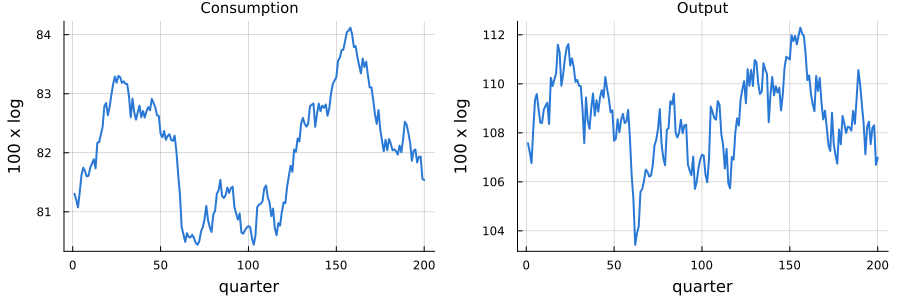

In [9]:
colorModel = "#2a78d6"      # blue
colorNW = "#eb6834"         # orange

p1 = plot(data.quarter, data.log_c, color = colorModel, linewidth = 2, legend = false, title = "Consumption", titlefontsize = 10,
          xlabel = "quarter", ylabel = "100 x log", gridalpha = 0.3)
p2 = plot(data.quarter, data.log_y, color = colorModel, linewidth = 2, legend = false, title = "Output", titlefontsize = 10,
          xlabel = "quarter", ylabel = "100 x log", gridalpha = 0.3)
plot(p1, p2, layout = (1, 2), size = (900, 300), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

### Setting up the MSM problem

`build_problem` creates the `MSMProblem` from the moment contributions of the data and from the shocks of the simulated sample (drawn once), exactly as in `RBC.ipynb`. `estimate_and_infer!` runs a local minimization with the weight matrix $W = \Sigma_0^{-1}$, then computes the standard errors and the J-test.

In [10]:
@everywhere function build_problem(contributions, simulationShocks; burnIn = 200, maxFuncEvals = 10000)

    problem = MSMProblem(options = MSMOptions(maxFuncEvals = maxFuncEvals, globalOptimizer = :dxnes, localOptimizer = :LBFGS))

    # Priors: [starting value, lower bound, upper bound]
    priors = OrderedDict{String,Array{Float64,1}}()
    priors["alpha"] = [0.3, 0.1, 0.6]
    priors["rho"] = [0.8, 0.0, 0.99]
    priors["log_std_z"] = [log(1.0), log(0.1), log(3.0)]    # std_z between 0.1% and 3%
    set_priors!(problem, priors)

    # Empirical moments
    empiricalMoments = OrderedDict{String,Array{Float64,1}}()
    for (name, value) in zip(momentNames, vec(mean(contributions, dims = 1)))
        empiricalMoments[name] = [value]
    end
    set_empirical_moments!(problem, empiricalMoments)

    # Simulated moments: same shocks for every θ
    set_simulate_empirical_moments!(problem, θ -> OrderedDict{String,Float64}(zip(momentNames, simulated_moments(θ, simulationShocks, burnIn = burnIn))))

    return problem
end

# Local minimization from x0 with the weight matrix inv(Sigma0), then inference with Sigma0
@everywhere function estimate_and_infer!(problem, Sigma0, x0, nObs, nSim)
    set_weight_matrix!(problem, Matrix(inv(Sigma0)))
    construct_objective_function!(problem)
    optimResults = msm_localmin(problem, x0, verbose = false)
    θ = Optim.minimizer(optimResults)
    set_Sigma0!(problem, Matrix(Sigma0))
    calculate_Avar!(problem, θ, tau = nObs / nSim)
    se = [calculate_se(problem, nObs, i) for i in 1:length(θ)]
    J, criticalValue = J_test(problem, θ, nObs, nSim, 0.05)
    return (θ = θ, se = se, J = J, reject = J > criticalValue, converged = Optim.converged(optimResults))
end

In [11]:
contributions = moment_contributions(data.log_c, data.log_y)
nObs = size(contributions, 1)       # number of observations used for the moments
nSim = simulationRatio * T          # length of the simulated sample

Random.seed!(5678)
simulationShocks = randn(1, nSim + burnIn)

myProblem = build_problem(contributions, simulationShocks, burnIn = burnIn)

DataFrame(moment = momentNames, data = vec(mean(contributions, dims = 1)),
          model_at_true_values = simulated_moments(trueValues, simulationShocks, burnIn = burnIn))

Row,moment,data,model_at_true_values
,String,Float64,Float64
1,mean_c,82.0676,83.7779
2,mean_y,108.715,110.596
3,var_c,0.902236,2.15062
4,var_y,2.75025,4.28451
5,cov_cy,1.26371,2.6292
6,autocov_c,0.887569,2.13981
7,autocov_y,2.44398,4.03506


### Step 1: estimation with a Newey-West $\Sigma_0$

$\Sigma_0$ is first estimated from the data, with the Newey-West estimator (`cov_NW`), and the weight matrix is $W = \Sigma_0^{-1}$. The global optimizer runs in parallel on the workers (each one solves and simulates its own copy of the model), and a local optimizer then refines its result.

In [12]:
Sigma0_NW = cov_NW(contributions)
set_weight_matrix!(myProblem, Matrix(inv(Sigma0_NW)))
construct_objective_function!(myProblem)

@time msm_optimize!(myProblem, verbose = false)
println("Global optimizer: minimizer = $(round.(msm_minimizer(myProblem), digits = 4)), minimum = $(msm_minimum(myProblem))")

msm_refine_globalmin!(myProblem, verbose = false)
println("Local refinement: minimizer = $(round.(msm_local_minimizer(myProblem), digits = 4)), minimum = $(msm_local_minimum(myProblem))")

step1 = estimate_and_infer!(myProblem, Sigma0_NW, msm_local_minimizer(myProblem), nObs, nSim)
println("True values                 = $(trueValues)")

 17.613322 seconds (5.73 M allocations: 302.923 MiB, 0.30% gc time, 10.85% compilation time: <1% of which was recompilation)
Global optimizer: minimizer = [0.327, 0.8159, -0.2683], minimum = 0.005176657667463918
Local refinement: minimizer = [0.327, 0.8159, -0.2683], minimum = 0.005176657667470681
True values                 = [0.33, 0.9, -0.35667494393873245]



True values                 = [0.33, 0.9, -0.35667494393873245]

### Step 2: model-based $\Sigma_0$

As in `RBC.ipynb`, $\Sigma_0$ is then simulated with the model at the step 1 estimate (Burnside and Eichenbaum, 1996): the variance of the moments across many datasets of length $T$. We re-estimate with $W = \Sigma_0^{-1}$, and repeat once at the new estimate.

**Reference**
* Burnside, Craig, and Martin Eichenbaum. "Small-sample properties of GMM-based Wald tests." Journal of Business & Economic Statistics 14.3 (1996): 294-308.

In [13]:
Random.seed!(91011)
Sigma0_model = model_Sigma0(step1.θ, T, nbSimulations = nbSimulationsSigma0, burnIn = burnIn)
step2 = estimate_and_infer!(myProblem, Sigma0_model, step1.θ, nObs, nSim)

Sigma0_model = model_Sigma0(step2.θ, T, nbSimulations = nbSimulationsSigma0, burnIn = burnIn)
step2 = estimate_and_infer!(myProblem, Sigma0_model, step2.θ, nObs, nSim)

DataFrame(moment = momentNames, std_Newey_West = sqrt.(diag(Sigma0_NW)), std_model_based = sqrt.(diag(Sigma0_model)))

Row,moment,std_Newey_West,std_model_based
,String,Float64,Float64
1,mean_c,2.6073,6.93556
2,mean_y,4.11236,7.95504
3,var_c,2.36996,5.1825
4,var_y,8.26608,9.24041
5,cov_cy,4.01802,6.06849
6,autocov_c,2.36593,5.18273
7,autocov_y,8.23605,9.17086


The table above compares the long-run standard deviations of the moment contributions under the two estimators. The table below gives the estimates, their standard errors and 95% confidence intervals.

In [14]:
z975 = quantile(Normal(), 0.975)    # 97.5% quantile of the normal distribution: 95% confidence intervals
results = DataFrame(Sigma0 = String[], parameter = String[], true_value = Float64[], estimate = Float64[], std_error = Float64[],
                    CI_lower = Float64[], CI_upper = Float64[], true_value_in_CI = Bool[])
for (label, step) in [("Newey-West", step1), ("model-based", step2)], i in 1:length(trueValues)
    lower = step.θ[i] - z975 * step.se[i]
    upper = step.θ[i] + z975 * step.se[i]
    push!(results, (label, parameterNames[i], trueValues[i], step.θ[i], step.se[i], lower, upper, lower <= trueValues[i] <= upper))
end
results

Row,Sigma0,parameter,true_value,estimate,std_error,CI_lower,CI_upper,true_value_in_CI
,String,String,Float64,Float64,Float64,Float64,Float64,Bool
1,Newey-West,alpha,0.33,0.327013,0.000346083,0.326335,0.327691,false
2,Newey-West,rho,0.9,0.815874,0.0225079,0.771759,0.859988,false
3,Newey-West,log_std_z,-0.356675,-0.268312,0.0768736,-0.418982,-0.117642,true
4,model-based,alpha,0.33,0.327242,0.000906305,0.325466,0.329019,false
5,model-based,rho,0.9,0.840739,0.0287775,0.784336,0.897141,false
6,model-based,log_std_z,-0.356675,-0.294412,0.0562122,-0.404586,-0.184238,true


### Back to $\sigma_z$

The third row of each block above is $x = \log(\sigma_z)$. As in `RBC.ipynb`, $\hat{\sigma}_z = \exp(\hat{x})$, its confidence interval applies $\exp$ to the two bounds of the interval for $x$, and its standard error comes from the Delta method: $se(\hat{\sigma}_z) \approx \exp(\hat{x}) \, se(\hat{x})$.

In [15]:
# std_z = exp(log_std_z), in percent
backTransformed = DataFrame(Sigma0 = String[], parameter = String[], true_value = Float64[], estimate = Float64[],
                            std_error_delta_method = Float64[], CI_lower = Float64[], CI_upper = Float64[])
for (label, step) in [("Newey-West", step1), ("model-based", step2)]
    x, se = step.θ[3], step.se[3]
    push!(backTransformed, (label, "std_z", exp(trueValues[3]), exp(x), exp(x) * se, exp(x - z975 * se), exp(x + z975 * se)))
end
backTransformed

Row,Sigma0,parameter,true_value,estimate,std_error_delta_method,CI_lower,CI_upper
,String,String,Float64,Float64,Float64,Float64,Float64
1,Newey-West,std_z,0.7,0.764669,0.0587829,0.657716,0.889014
2,model-based,std_z,0.7,0.74497,0.0418764,0.667253,0.831738


In [16]:
# J-test (4 over-identifying restrictions), with the model-based Sigma0: MSM.jl's summary table and test
minimizer = step2.θ
show(stdout, MIME("text/plain"), summary_table(myProblem, minimizer, nObs, 0.05))
J, criticalValue = J_test(myProblem, minimizer, nObs, nSim, 0.05)
println("\nJ-test: J = $(round(J, digits = 2)), critical value at 5% = $(round(criticalValue, digits = 2)): the model is $(J > criticalValue ? "rejected" : "not rejected")")

──────────────────────────────────────────────────────────────────
        Coef.   Std. Error       t  Pr(>|t|)   CI Lower   CI Upper
──────────────────────────────────────────────────────────────────
x1   0.327242  0.000906305  361.07    <1e-99   0.325466   0.329019
x2   0.840739  0.0287775     29.22    <1e-99   0.784336   0.897141
x3  -0.294412  0.0562122     -5.24    <1e-06  -0.404586  -0.184238
──────────────────────────────────────────────────────────────────
J-test: J = 4.26, critical value at 5% = 9.49: the model is not rejected


        Coef.   Std. Error       t  Pr(>|t|)   CI Lower   CI Upper
──────────────────────────────────────────────────────────────────
x1   0.327242  0.000906305  361.07    <1e-99   0.325466   0.329019
x2   0.840739  0.0287775     29.22    <1e-99   0.784336   0.897141
x3  -0.294412  0.0562122     -5.24    <1e-06  -0.404586  -0.184238
──────────────────────────────────────────────────────────────────
J-test: J = 4.26, critical value at 5% = 9.49: the model is not rejected


### Slices of the objective function

The objective function around the estimate, one parameter at a time (model-based weight matrix). The third panel shows $\sigma_z = \exp(x)$ on its horizontal axis, instead of $x = \log(\sigma_z)$.

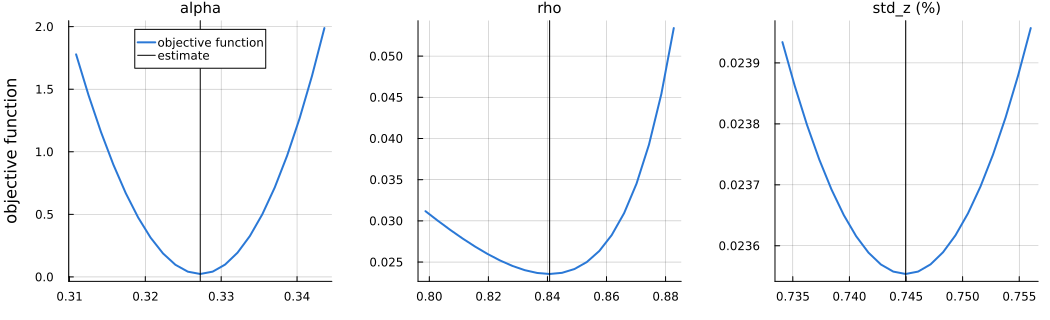

In [17]:
vXGrid, vYGrid = msm_slices(myProblem, minimizer, nbPoints = 21, offset = 0.05)

# The third parameter is log(std_z): shown as std_z = exp(log_std_z), in percent
sliceNames = ["alpha", "rho", "std_z (%)"]
sliceTransforms = [identity, identity, exp]

slicePanels = []
for i in 1:length(minimizer)
    f = sliceTransforms[i]
    p = plot(f.(vXGrid[:, i]), vYGrid[:, i], color = colorModel, linewidth = 2, label = "objective function", title = sliceNames[i], titlefontsize = 10,
             ylabel = i == 1 ? "objective function" : "", gridalpha = 0.3, legend = i == 1 ? :top : false)
    vline!(p, [f(minimizer[i])], color = :black, linewidth = 1, label = "estimate")
    push!(slicePanels, p)
end
plot(slicePanels..., layout = (1, 3), size = (1050, 320), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

### Results

**Same data and same estimates as `RBC.ipynb`.** The fake data simulated with Dynare.jl differ from those simulated with MacroModelling.jl in `RBC.ipynb` by at most $10^{-13}$: the two packages compute the same first-order solution. The MSM estimates, their standard errors and the J statistic are then the same as in `RBC.ipynb`, to all the digits shown. With the model-based $\Sigma_0$: $\hat{\alpha} = 0.3272$ (standard error 0.0009), $\hat{\rho} = 0.841$ (0.029) and $\log(\hat{\sigma}_z) = -0.294$ (0.056), that is $\hat{\sigma}_z = 0.745$% with a 95% confidence interval of [0.667, 0.832] (true value 0.7%). The J-test does not reject the model (J = 4.26, critical value 9.49). As in `RBC.ipynb`, the true values of $\alpha$ and $\rho$ fall outside their 95% confidence intervals with this particular dataset; the Monte Carlo of `RBC.ipynb` studies the coverage of these intervals.

**What Dynare.jl requires.**

* **One folder per process.** Dynare.jl writes the files of its preprocessor next to the model file, so each process loads its own copy of `RBC.mod` in a temporary folder. 
* **First order only.** Dynare.jl only computes first-order solutions, so the misspecification exercise of `RBC.ipynb` (a true model solved at third order, estimated at first order) cannot be done with it.

In [19]:
versioninfo()

Julia Version 1.13.1
Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


---

## Extra: Dynare's own simulated method of moments (Octave)

This optional section estimates the model again with the `method_of_moments` command of **Dynare for MATLAB and Octave** (Dynare 6), as an independent check of MSM.jl. Dynare.jl does not have (yet) this command. The section requires [GNU Octave](https://octave.org) (or MATLAB) and [Dynare](https://www.dynare.org) 6 or later, installed outside of Julia; it was written with Octave 8.4 and Dynare 6.0. If Octave is not found, the section is skipped.

**How Octave is called.** Octave runs as an external program, like any command in a terminal (see [Running External Programs](https://docs.julialang.org/en/v1/manual/running-external-programs/) in Julia's manual), instead of inside the Julia process. Julia writes the data and a copy of the model file [`RBC_mom.mod`](RBC_mom.mod) to a temporary folder (Dynare writes its own files there too), runs an Octave script in that folder, and reads back the CSV files that the script writes with the results.

**What differs from the MSM.jl estimation above.** The estimates should be close to those of MSM.jl, but not identical:

* **Same model and moments, written differently.** `RBC_mom.mod` contains the model of `RBC.mod`, and declares the observed series and the 7 moments of this notebook (`matched_moments` block). Dynare's matched moments are *uncentered*: $E[x]$, $E[x^2]$, $E[x y]$, $E[x_t x_{t-1}]$. Hence, both the data and the model series are shifted by the mean of the data ($x = 100 \log(c) - \bar{x}$). The shifts are passed to Dynare on its command line (`-DSHIFT_C=...`).
* **Weighting matrix.** Dynare estimates in two stages: with a diagonal weighting matrix, then with the optimal one, the inverse of the Newey-West estimate of $\Sigma_0$ from the data (Bartlett kernel, 20 lags by default; `cov_NW` uses 7 lags here). The natural comparison is therefore step 1 above (Newey-West $\Sigma_0$), not step 2 (model-based $\Sigma_0$).
* **Simulated shocks and optimizer.** Dynare draws its own shocks (with a fixed seed), for a simulated sample of 10 times the length of the data after a burn-in of 200 periods, as above. It runs a local optimizer (`mode_compute = 4`, csminwel) from the starting values of the MSM priors, while MSM.jl first runs a global search.

In [20]:
octave = Sys.which("octave")

if octave === nothing
    println("Octave was not found: this section is skipped")
else
    # Temporary folder with the model file and the shifted data
    momFolder = mktempdir()
    cp("RBC_mom.mod", joinpath(momFolder, "RBC_mom.mod"))
    shiftC, shiftY = mean(data.log_c), mean(data.log_y)
    CSV.write(joinpath(momFolder, "observed_shifted.csv"), DataFrame(log_c = data.log_c .- shiftC, log_y = data.log_y .- shiftY))

    # Octave script: runs Dynare, then writes the estimates, their standard errors and the J-test to CSV files
    script = """
    dynare RBC_mom noclearall nolog -DSHIFT_C=$(repr(shiftC)) -DSHIFT_Y=$(repr(shiftY))
    names = fieldnames(oo_.mom.smm_mode.parameters);
    f = fopen('dynare_smm_estimates.csv', 'w');
    fprintf(f, 'parameter,estimate,std_error\\n');
    for i = 1:numel(names)
        fprintf(f, '%s,%.15g,%.15g\\n', names{i}, oo_.mom.smm_mode.parameters.(names{i}), oo_.mom.smm_std_at_mode.parameters.(names{i}));
    end
    fclose(f);
    f = fopen('dynare_smm_J_test.csv', 'w');
    fprintf(f, 'J,degrees_freedom,p_value\\n%.15g,%d,%.15g\\n', oo_.mom.J_test.j_stat, oo_.mom.J_test.degrees_freedom, oo_.mom.J_test.p_val);
    fclose(f);
    """
    write(joinpath(momFolder, "run_mom.m"), script)

    # Runs Octave in the temporary folder, and keeps what it prints
    @time octaveOutput = read(Cmd(`$octave --no-gui --quiet run_mom.m`, dir = momFolder), String)

    # Dynare's summary of the estimation
    println(octaveOutput[first(findfirst("RESULTS FROM SMM", octaveOutput)):end])

    dynareSMM = CSV.read(joinpath(momFolder, "dynare_smm_estimates.csv"), DataFrame)
    dynareJ = CSV.read(joinpath(momFolder, "dynare_smm_J_test.csv"), DataFrame)
end

  4.184463 seconds (13.48 k allocations: 808.930 KiB, 0.69% compilation time)
RESULTS FROM SMM ESTIMATION
parameters
            Estimate    s.d. t-stat

alpha         0.3277  0.0004 788.8377 
rho           0.8320  0.0224 37.1053 
log_std_z    -0.2863  0.0607  4.7189 


Value of J-test statistic: 0.583583
p-value of J-test statistic: 0.964870


Comparison of matched data moments and model moments (SMM)
Moment                      Data       Model
E[log_c]               0.0000000  -0.0341790
E[log_y]              -0.0000000  -0.1273145
E[log_c*log_c]         0.9005995   0.8713190
E[log_y*log_y]         2.7429241   2.5211073
E[log_c*log_y]         1.2616873   1.1628860
E[log_c*log_c(-1)]     0.8875692   0.8617814
E[log_y*log_y(-1)]     2.4439833   2.2107245

==== Method of Moments Estimation (SMM) Completed ====

Total computing time : 0h00m04s



Row,J,degrees_freedom,p_value
,Float64,Int64,Float64
1,0.583583,4,0.96487


In [21]:
# Dynare's SMM against MSM.jl (step 1: Newey-West Sigma0; step 2: model-based Sigma0), on the same fake data
if octave !== nothing
    @assert dynareSMM.parameter == parameterNames
    momComparison = DataFrame(parameter = parameterNames, true_value = trueValues,
                              MSM_step1 = step1.θ, MSM_step1_se = step1.se,
                              Dynare_SMM = dynareSMM.estimate, Dynare_SMM_se = dynareSMM.std_error,
                              MSM_step2 = step2.θ, MSM_step2_se = step2.se)
    println("J statistic: Dynare SMM $(round(dynareJ.J[1], digits = 2)) (p-value $(round(dynareJ.p_value[1], digits = 3))), ",
            "MSM.jl step 1 $(round(step1.J, digits = 2)), MSM.jl step 2 $(round(step2.J, digits = 2))")
    momComparison
end

J statistic: Dynare SMM 0.58 (p-value 0.965), MSM.jl step 1 0.94, MSM.jl step 2 4.26


Row,parameter,true_value,MSM_step1,MSM_step1_se,Dynare_SMM,Dynare_SMM_se,MSM_step2,MSM_step2_se
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,alpha,0.33,0.327013,0.000346083,0.327658,0.000415367,0.327242,0.000906305
2,rho,0.9,0.815874,0.0225079,0.83201,0.022423,0.840739,0.0287775
3,log_std_z,-0.356675,-0.268312,0.0768736,-0.286275,0.0606653,-0.294412,0.0562122


**Results.** Dynare's SMM gives $\hat{\alpha} = 0.3277$ (standard error 0.0004), $\hat{\rho} = 0.832$ (0.022) and $\log(\hat{\sigma}_z) = -0.286$ (0.061), with a J statistic of 0.58 (p-value 0.96). These are close to the estimates of MSM.jl with the same kind of weighting matrix (step 1, Newey-West $\Sigma_0$): $0.3270$ (0.0003), $0.816$ (0.023) and $-0.268$ (0.077), with J = 0.94. The differences in $\rho$ and $\log(\sigma_z)$ are well within one standard error; for $\alpha$, whose standard error is very small, the difference (0.0006) is less than two standard errors. The standard errors are of the same size, and both J statistics are small, as expected with a Newey-West $\Sigma_0$ (see the Monte Carlo of `RBC.ipynb`, where it underestimates the variance of these persistent series). 

The two implementations, written independently, therefore agree, given the differences listed above (simulated shocks, Newey-West lags, uncentered moments, optimizer). Running Dynare in Octave took about 4 seconds.